In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

# Lendo o arquivo

In [2]:
file = '/home/ufba/ufba/vitor/Rotinas/vento_2024.nc'
vento = xr.open_dataset(file)

# Selecionando lat/lon
vento = vento.sel(latitude=slice(-15, -30), longitude=slice(-50, -35))

# Selecionando tempo
#datai = pd.Timestamp(year=2024, month=6, day=30)
#dataf = pd.Timestamp(year=2024, month=8, day=31, hour=23)
#vento = vento.sel(valid_time=slice(datai,dataf))

vento = vento.isel(valid_time=slice(0, None, 8))

meses = vento.valid_time.dt.month

verao = vento.sel(valid_time=(meses.isin([12, 1, 2])))
outono = vento.sel(valid_time=(meses.isin([3, 4, 5])))
inverno = vento.sel(valid_time=(meses.isin([6, 7, 8])))
primavera = vento.sel(valid_time=(meses.isin([9, 10, 11])))

lon = vento.longitude
lat = vento.latitude

In [3]:
U10 = np.sqrt(vento.u10**2 + vento.v10**2)

In [4]:
print(np.min(U10))
print(np.max(U10))

<xarray.DataArray ()> Size: 4B
array(0.00144983, dtype=float32)
Coordinates:
    number   int64 8B 0
<xarray.DataArray ()> Size: 4B
array(20.070833, dtype=float32)
Coordinates:
    number   int64 8B 0


# Fórmula Coeficiente de arrasto

In [5]:
def cd(U10):
    return ((2.7/U10) + 0.142 + (0.076*U10))*10**-3

In [6]:
coeficiente = ((2.7/U10) + 0.142 + (0.076*U10))*10**-3
coeficiente

<xarray.DataArray (valid_time: 366, latitude: 61, longitude: 61)> Size: 5MB
array([[[0.00246521, 0.00282936, 0.00254509, ..., 0.00106029,
         0.00106199, 0.00106434],
        [0.0023734 , 0.00242137, 0.00216379, ..., 0.00105829,
         0.00105883, 0.00106184],
        [0.00277875, 0.00207747, 0.00188354, ..., 0.00105766,
         0.00105859, 0.00106331],
        ...,
        [0.00142133, 0.00174634, 0.00173834, ..., 0.00124778,
         0.0012583 , 0.00127315],
        [0.0011056 , 0.00117859, 0.00118252, ..., 0.00119374,
         0.00119387, 0.00119609],
        [0.00106308, 0.00108223, 0.00109097, ..., 0.00112359,
         0.00112401, 0.00112615]],

       [[0.00207448, 0.00336749, 0.00270902, ..., 0.00108601,
         0.00107293, 0.00106252],
        [0.00247676, 0.00310691, 0.00272308, ..., 0.00107668,
         0.00107277, 0.00106482],
        [0.00325805, 0.00582668, 0.00241385, ..., 0.00106801,
         0.00106635, 0.00106669],
...
        [0.0014046 , 0.00128771, 0.00114079, ..., 0.00114234,
         0.00115775, 0.00117758],
        [0.0011567 , 0.00110741, 0.00106713, ..., 0.00109229,
         0.00110037, 0.00110621],
        [0.00107697, 0.00105736, 0.00105526, ..., 0.00108094,
         0.00107363, 0.00107184]],

       [[0.00174253, 0.00244917, 0.00342954, ..., 0.00104816,
         0.00104937, 0.00105057],
        [0.00152421, 0.00191683, 0.0028253 , ..., 0.00104821,
         0.00104917, 0.00105034],
        [0.00147075, 0.00168989, 0.00215297, ..., 0.00104842,
         0.00104945, 0.00105008],
        ...,
        [0.00112384, 0.00105283, 0.00105602, ..., 0.0010639 ,
         0.00106883, 0.00107461],
        [0.00105657, 0.00106225, 0.00105479, ..., 0.0010768 ,
         0.00108091, 0.00108379],
        [0.0010854 , 0.00107397, 0.00106175, ..., 0.00117054,
         0.00114166, 0.0011366 ]]], shape=(366, 61, 61), dtype=float32)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude    (latitude) float64 488B -15.0 -15.25 -15.5 ... -29.75 -30.0
  * longitude   (longitude) float64 488B -50.0 -49.75 -49.5 ... -35.25 -35.0
    expver      (valid_time) <U4 6kB '0001' '0001' '0001' ... '0001' '0001'

# Fórmula Tensão de cisalhamento

In [7]:
def tensao_cisalhamento(U10, cd):
    rho_a=1.225 # Densidade do ar
    return rho_a * cd * U10**2

- cd

- Rotacional (dv/dx) - (du/dy)

In [8]:
u = vento.u10.values  # componente zonal [m/s] (shape: [lat, lon])
v = vento.v10.values  # componente meridional [m/s] (shape: [lat, lon])
lat = vento.latitude.values  # array de latitudes [graus]
lon = vento.longitude.values  # array de longitudes [graus]

# Constante da Terra
R = 6.371e6  # raio médio da Terra em metros

# Conversão de lat/lon para radianos
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Espaçamento em metros
dy = np.gradient(lat_rad) * R  # variação latitudinal em m
dx = np.gradient(lon_rad) * R * np.cos(lat_rad[:, np.newaxis])  # variação longitudinal em m

# Derivadas centradas
dv_dx = np.gradient(v, axis=1) / dx  # dv/dx
du_dy = np.gradient(u, axis=0) / dy[:, np.newaxis]  # du/dy

# Vorticidade (rotacional)
vorticidade = dv_dx - du_dy  # [1/s]

In [9]:
# verão
u_verao = verao.u10.values
v_verao = verao.v10.values


# outono
u_outono= outono.u10.values
v_outono = outono.v10.values


# inverno
u_inverno= inverno.u10.values
v_inverno= inverno.v10.values


# primavera
u_primavera= primavera.u10.values
v_primavera= primavera.v10.values


In [10]:
# Constante da Terra
R = 6.371e6  # raio médio da Terra em metros

# Latitude e longitude
lat = vento.latitude.values  # [graus]
lon = vento.longitude.values  # [graus]
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Espaçamento em metros
dy = np.gradient(lat_rad) * R  # [m]
dx = np.gradient(lon_rad) * R * np.cos(lat_rad[:, np.newaxis])  # [m]

# Função para calcular o rotacional
def calcular_rotacional(u, v):
    dv_dx = np.gradient(v, axis=1) / dx
    du_dy = np.gradient(u, axis=0) / dy[:, np.newaxis]
    return dv_dx - du_dy

# Cálculo por estação
rotacional_verao = calcular_rotacional(u_verao, v_verao)
rotacional_verao = np.mean(rotacional_verao, axis=0)

rotacional_outono = calcular_rotacional(u_outono, v_outono)
rotacional_outono = np.mean(rotacional_outono, axis=0)

rotacional_inverno = calcular_rotacional(u_inverno, v_inverno)
rotacional_inverno = np.mean(rotacional_inverno, axis=0)

rotacional_primavera = calcular_rotacional(u_primavera, v_primavera)
rotacional_primavera = np.mean(rotacional_primavera, axis=0)

- Tensão de Cisalhamento

In [11]:
vel_verao = np.sqrt(u_verao**2 + v_verao**2)
vel_outono = np.sqrt(u_outono**2 + v_outono**2)
vel_inverno = np.sqrt(u_inverno**2 + v_inverno**2)
vel_primavera = np.sqrt(u_primavera**2 + v_primavera**2)

In [12]:
coef_verao = ((2.7/vel_verao) + 0.142 + (0.076*vel_verao))*10**-3
coef_outono = ((2.7/vel_outono) + 0.142 + (0.076*vel_outono))*10**-3
coef_inverno = ((2.7/vel_inverno) + 0.142 + (0.076*vel_inverno))*10**-3
coef_primavera = ((2.7/vel_primavera) + 0.142 + (0.076*vel_primavera))*10**-3

In [13]:
T_verao = tensao_cisalhamento(U10=vel_verao, cd=coef_verao)
T_outono = tensao_cisalhamento(U10=vel_outono, cd=coef_outono)
T_inverno = tensao_cisalhamento(U10=vel_inverno, cd=coef_inverno)
T_primavera = tensao_cisalhamento(U10=vel_primavera, cd=coef_primavera)


# Plots

- Rotacional

/tmp/ipykernel_110427/1493676605.py:78: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.05, hspace=0.1)


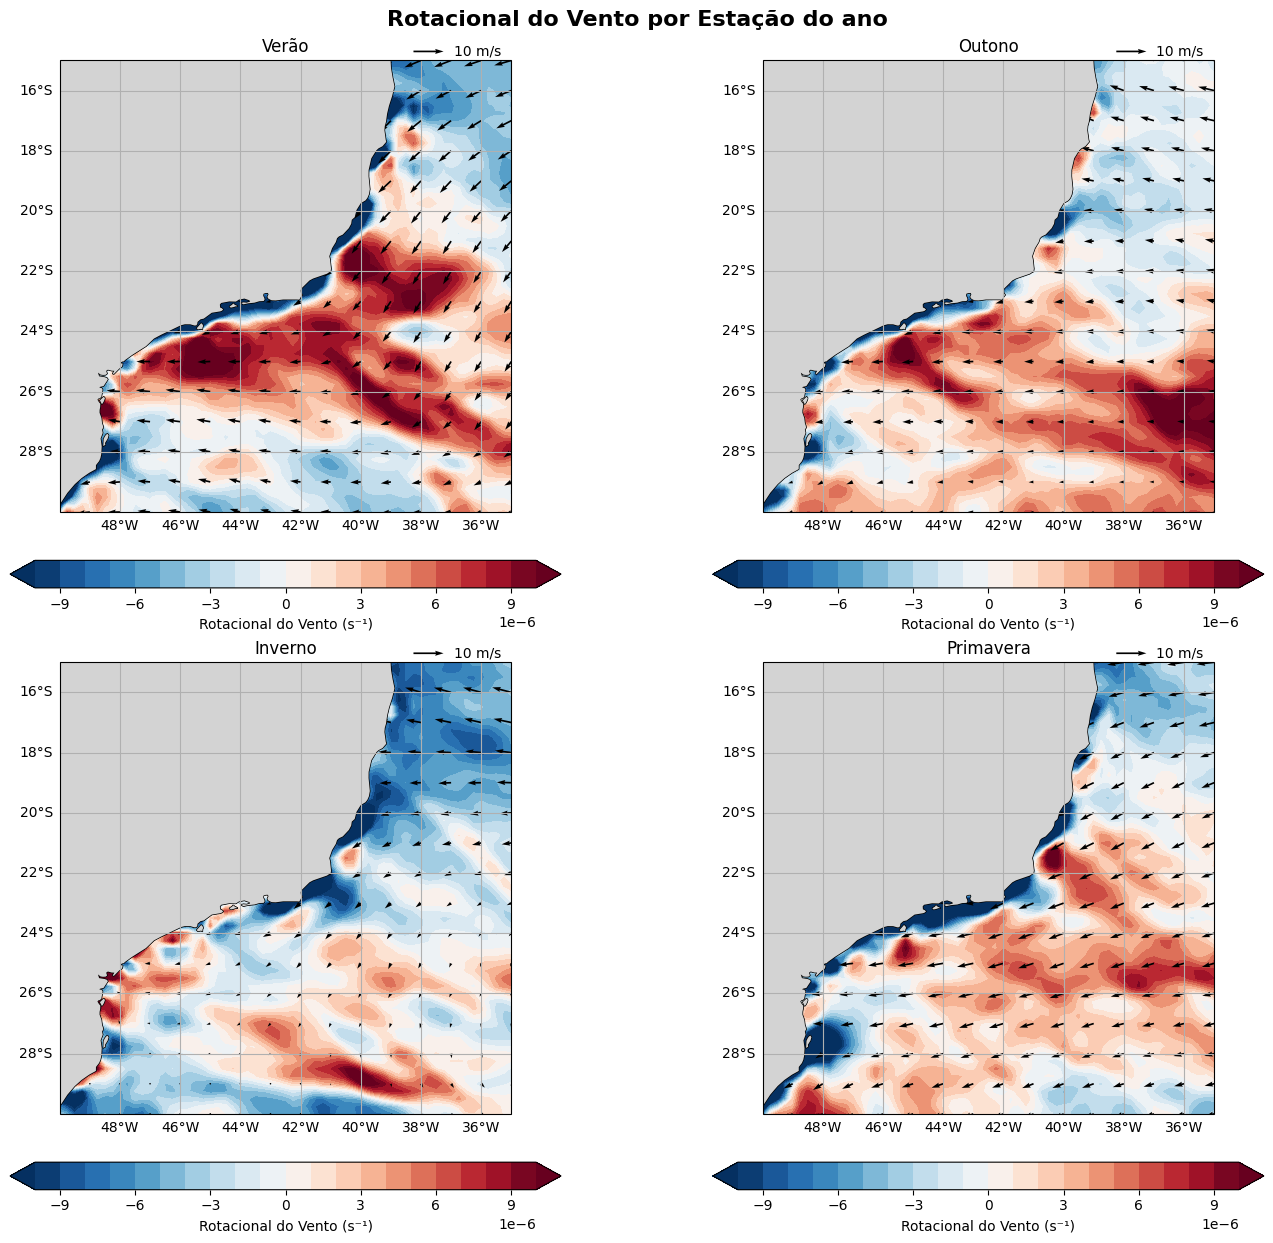

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Criando a figura
fig, axs = plt.subplots(2, 2, figsize=(14, 12),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)

# Títulos e dados organizados
titulos = ['Verão', 'Outono', 'Inverno', 'Primavera']

# Cálculo da média no tempo
rotacionais = [rotacional_verao, rotacional_outono, rotacional_inverno, rotacional_primavera]
us = [np.mean(u_verao, axis=0), np.mean(u_outono, axis=0), np.mean(u_inverno, axis=0), np.mean(u_primavera, axis=0)]
vs = [np.mean(v_verao, axis=0), np.mean(v_outono, axis=0), np.mean(v_inverno, axis=0), np.mean(v_primavera, axis=0)]

# Configurações comuns
land_feature = cfeature.LAND.with_scale('50m')
coast_feature = cfeature.COASTLINE.with_scale('50m')
borders_feature = cfeature.BORDERS.with_scale('50m')

# Níveis para o contorno
levels = np.linspace(-1e-5, 1e-5, 21)

# Criando grid de coordenadas para os vetores
lon_grid, lat_grid = np.meshgrid(lon, lat)  # lon: eixo x, lat: eixo y

# Plotando cada subplot
for i, ax in enumerate(axs.flat):
    # Adicionando as features de costa e fronteiras
    ax.add_feature(coast_feature, linewidth=0.5)
    ax.add_feature(borders_feature, linestyle=':', linewidth=0.5)
    
    # Plotando o rotacional
    mesh = ax.contourf(lon, lat, rotacionais[i], levels=levels,
                       cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
    
    # Adicionando o feature de terra em cinza
    ax.add_feature(land_feature, facecolor='lightgray', zorder=2)  # zorder para garantir que fique sobre o rotacional
    ax.add_feature(coast_feature)
    ax.add_feature(borders_feature)
    
    # Subamostragem para vetores
    step = 4
    u_plot = us[i]
    v_plot = vs[i]

    # Verifica se as dimensões são compatíveis com lon_grid e lat_grid
    if u_plot.shape != lon_grid.shape:
        u_plot = u_plot.T
        v_plot = v_plot.T

    # Plotando vetores de vento
    q = ax.quiver(
        lon_grid[::step, ::step], lat_grid[::step, ::step],
        u_plot[::step, ::step], v_plot[::step, ::step],
        scale=150, color='black', transform=ccrs.PlateCarree()
    )
    
    # Barra de cores
    cbar = fig.colorbar(mesh, ax=ax, orientation='horizontal',
                        pad=0.05, shrink=0.8)
    cbar.set_label('Rotacional do Vento (s⁻¹)')
    
    # Título e grid
    ax.set_title(titulos[i])
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    
    # Escala dos vetores
    ax.quiverkey(q, 0.85, 1.02, 10, '10 m/s', labelpos='E',
                 coordinates='axes')

# Ajustes finais
plt.subplots_adjust(wspace=0.05, hspace=0.1)
fig.suptitle('Rotacional do Vento por Estação do ano', fontsize=16, y=1.02, fontweight='bold')
plt.show()


- Tensão de cisalhamento

NameError: name 'T' is not defined

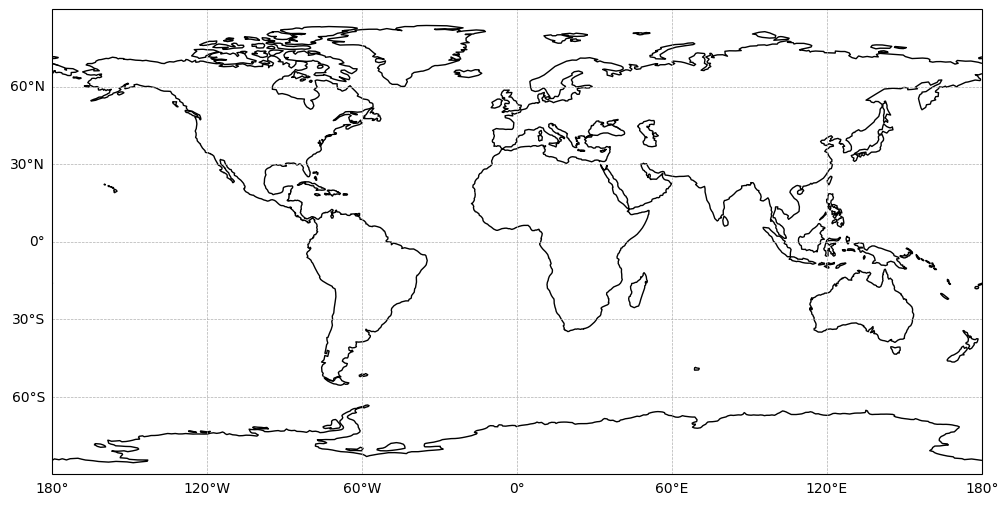

In [15]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
gridlines = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gridlines.top_labels = False
gridlines.right_labels = False

# Define limites de cor para aplicar o 'extend'
vmin = np.nanmin(T)
vmax = np.nanmax(T)

# Plotando o contorno preenchido
contour = ax.contourf(lon, lat, T, levels=100, cmap='jet', 
                      vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())

# Adicionando linhas de contorno (em preto, por exemplo)
contour_lines = ax.contour(lon, lat, T, levels=10,  # Níveis reduzidos para melhor legibilidade
                           colors='black', linewidths=0.5, 
                           transform=ccrs.PlateCarree())

# Adiciona rótulos aos contornos (valores numéricos)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.3f')  # 1 casa decimal

# Colorbar com pontas arredondadas
cb = plt.colorbar(contour, ax=ax, orientation='vertical', pad=0.05, shrink=0.7, extend='both')

# Título
ax.set_title('Média da Tensão de Cisalhamento do Vento ($T$) - Junho de 2024', fontsize=14, fontweight='bold')

In [ ]:
file = 'AS_atm_sum_win.nc'
wind = xr.open_dataset(file)
wind

<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 1464, latitude: 321, longitude: 361)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 12kB 2024-01-01 ... 2024-12-31T21...
  * latitude    (latitude) float64 3kB 20.0 19.75 19.5 ... -59.5 -59.75 -60.0
  * longitude   (longitude) float64 3kB -70.0 -69.75 -69.5 ... 19.5 19.75 20.0
    expver      (valid_time) <U4 23kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 679MB ...
    v10         (valid_time, latitude, longitude) float32 679MB ...
    lsm         (valid_time, latitude, longitude) float32 679MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-05T15:09 GRIB to CDM+CF via cfgrib-0.9.1...

# Transporte vertical

In [ ]:
'''definindo coriolis'''
lats=np.zeros_like(ds['u10'][0,: ,:])
def coriolis(lat):
        return 2*(7.2921159*(10**(-5)))*np.sin(np.deg2rad(lat))
for i in range(lats.shape[0]):
    for j in range(lats.shape[1]):
        lats[i, j] = lat[i]
cor=coriolis(lats)


'''Criando medias sazonais da tensão de cisalhamento do vento'''
current_data=tempo[0]
data_final=tempo[-1]

verao_u=[]
verao_v=[]
verao_w=[]

outono_u=[]
outono_v=[]

outono_w=[]

inverno_u=[]
inverno_v=[]
inverno_w=[]

primavera_u=[]
primavera_v=[]
primavera_w=[]

while current_data <= data_final:
    if str(current_data.strftime('%m')) in ['01','02','12']:
        verao_u.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]))
        verao_v.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]))
        verao_w.append((np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]),27.5*1000,axis=1)-np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]),27.5*1000,axis=0))/(1025*cor))

        print(str(current_data))
        current_data = current_data + datetime.timedelta(days=1)
    elif str(current_data.strftime('%m')) in ['03','04','05']:
        outono_u.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]))
        outono_v.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]))
        outono_w.append((np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]),27.5*1000,axis=1)-np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]),27.5*1000,axis=0))/(1025*cor))

        print(str(current_data))
        current_data = current_data + datetime.timedelta(days=1)

    elif str(current_data.strftime('%m')) in ['06','07','08']:
        inverno_u.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]))
        inverno_v.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]))
        inverno_w.append((np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]),27.5*1000,axis=1)-np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]),27.5*1000,axis=0))/(1025*cor))
        print(str(current_data))
        current_data = current_data + datetime.timedelta(days=1)
    elif str(current_data.strftime('%m')) in ['09','10','11']:
        primavera_u.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]))
        primavera_v.append((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]))
        primavera_w.append((np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*v[tempo.index(current_data),:,:]),27.5*1000,axis=1)-np.gradient((1.225*0.0015*np.sqrt(u[tempo.index(current_data),:,:]**2+v[tempo.index(current_data),:,:]**2)*u[tempo.index(current_data),:,:]),27.5*1000,axis=0))/(1025*cor))
        print(str(current_data))
        current_data = current_data + datetime.timedelta(days=1)

'''calculando as medias'''
verao_u_media=np.mean(np.ma.stack(verao_u,2),axis=2)
verao_v_media=np.mean(np.ma.stack(verao_v,2),axis=2)
mag_verao=np.sqrt(verao_u_media**2+verao_v_media**2)
verao_wek=np.mean(np.ma.stack(verao_w,2),axis=2)

outono_u_media=np.mean(np.ma.stack(outono_u,2),axis=2)
outono_v_media=np.mean(np.ma.stack(outono_v,2),axis=2)
mag_outono=np.sqrt(outono_u_media**2+outono_v_media**2)
outono_wek=np.mean(np.ma.stack(outono_w,2),axis=2)

inverno_u_media=np.mean(np.ma.stack(inverno_u,2),axis=2)
inverno_v_media=np.mean(np.ma.stack(inverno_v,2),axis=2)
mag_inverno=np.sqrt(inverno_u_media**2+inverno_v_media**2)

inverno_wek=np.mean(np.ma.stack(inverno_w,2),axis=2)

primavera_u_media=np.mean(np.ma.stack(primavera_u,2),axis=2)
primavera_v_media=np.mean(np.ma.stack(primavera_v,2),axis=2)
mag_primavera=np.sqrt(primavera_u_media**2+primavera_v_media**2)
primavera_wek=np.mean(np.ma.stack(primavera_w,2),axis=2)

'''plotando'''
fig=plt.figure(figsize=(7,6.5))
#fig, axes = plt.subplots(2, 2,projection= ccrs.PlateCarree(), figsize=(12,10))
levels = np.linspace(-4*10**(-6),4*10**(-6),11)
# Subplot 1: Verão
ax1 = fig.add_subplot(2,2,1, projection=ccrs.PlateCarree())
contour1 = ax1.contourf(lon, lat,verao_wek, levels=levels, transform=ccrs.PlateCarree(), cmap="jet", vmin=-4*10**(-6), vmax=4*10**(-6))
ax1.quiver(lon[::],lat[::],(verao_u_media[::,::]/mag_verao[::,::]),verao_v_media[::,::]/mag_verao[::,::],transform=ccrs.PlateCarree(),pivot='middle',scale=4,scale_units='x',units='x',width=0.03)
ax1.set_title('Verão')
ax1.coastlines()
g1 = ax1.gridlines(crs=ccrs.PlateCarree(), linestyle='-.', color='gray', draw_labels=True)
g1.right_labels = False
g1.top_labels = False
g1.bottom_labels = False  
# Subplot 2:outono
ax2 = fig.add_subplot(2,2,2, projection=ccrs.PlateCarree())
contour2 = ax2.contourf(lon, lat,outono_wek, levels=levels, transform=ccrs.PlateCarree(), cmap="jet", vmin=-4*10**(-6), vmax=4*10**(-6))
ax2.quiver(lon[::],lat[::],(outono_u_media[::,::]/mag_outono[::,::]),outono_v_media[::,::]/mag_outono[::,::],transform=ccrs.PlateCarree(), color='black' ,pivot='middle',scale=4,scale_units='x',units='x',width=0.03)
ax2.set_title('outono')
ax2.coastlines()
g2 = ax2.gridlines(crs=ccrs.PlateCarree(), linestyle='-.', color='gray', draw_labels=False)
g2.right_labels = False
g2.top_labels = False
g2.left_labels = False  
g2.bottom_labels = False  

# Subplot 3:inverno
ax3 = fig.add_subplot(2,2,3, projection=ccrs.PlateCarree())
contour3 = ax3.contourf(lon, lat,inverno_wek, levels=levels, transform=ccrs.PlateCarree(), cmap="jet", vmin=-4*10**(-6), vmax=4*10**(-6))
ax3.quiver(lon[::],lat[::],(inverno_u_media[::,::]/mag_inverno[::,::]),inverno_v_media[::,::]/mag_inverno[::,::],transform=ccrs.PlateCarree(), color='black',pivot='middle',scale=4,scale_units='x',units='x',width=0.03)
ax3.set_title('Inverno')
ax3.coastlines()
g3 = ax3.gridlines(crs=ccrs.PlateCarree(), linestyle='-.', color='gray',draw_labels=True)
g3.right_labels = False
g3.top_labels = False

# Subplot 4:primavera
ax4 = fig.add_subplot(2,2,4, projection=ccrs.PlateCarree())
contour4 = ax4.contourf(lon, lat,primavera_wek, levels=levels, transform=ccrs.PlateCarree(), cmap="jet", vmin=-4*10**(-6), vmax=4*10**(-6),extend='both')
ax4.quiver(lon[::],lat[::],(primavera_u_media[::,::]/mag_primavera[::,::]),primavera_v_media[::,::]/mag_primavera[::,::],transform=ccrs.PlateCarree(), color='black',pivot='middle',scale=4,scale_units='x',units='x',width=0.03)
ax4.set_title('primavera')
ax4.coastlines()
g4 = ax4.gridlines(crs=ccrs.PlateCarree(), linestyle='-.', color='gray', draw_labels=True)
g4.right_labels = False
g4.top_labels = False
g4.left_labels = False


plt.tight_layout()
pos1 = ax2.get_position()
pos2 = ax4.get_position()

cb_ax = fig.add_axes([
    pos1.x1 + 0.01,        # à direita dos plots
    pos2.y0,               # altura começa no subplot de baixo
    0.01,                  # largura da colorbar
    pos1.y1 - pos2.y0      # altura total (do topo de cima até base de baixo)
])

cbar = fig.colorbar(contour4, cax=cb_ax,extend='both')
plt.suptitle('bombeamento de ekman')
#plt.savefig('teste.png')
#exit()
plt.show()

